In [ ]:
a = 2004

In [ ]:
!pip install -q opencv-python
!apt install -q ffmpeg
!pip install -q openai
!pip install opencv-python
!apt install ffmpeg
!pip install easydict
!pip install einops
!pip install peft
!pip install timm
!pip install -U bitsandbytes
!pip install moviepy
!pip install decord
!pip install av
!pip install -q bitsandbytes
!pip install -q accelerate==0.34.2

Reading package lists...
Building dependency tree...
Reading state information...
ffmpeg is already the newest version (7:4.4.2-0ubuntu0.22.04.1).
0 upgraded, 0 newly installed, 0 to remove and 1 not upgraded.
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
ffmpeg is already the newest version (7:4.4.2-0ubuntu0.22.04.1).
0 upgraded, 0 newly installed, 0 to remove and 1 not upgraded.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.1/59.1 MB 8.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.6/13.6 MB 35.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.5/40.5 MB 9.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 324.4/324.4 kB 6.9 MB/s eta 0:00:00


In [ ]:
# Create clean dataset dirs
!mkdir -p /content/helmet_synth/helmet
!mkdir -p /content/helmet_synth/no_helmet

# Copy your images
!cp -r extracted/output_2/helmet/* /content/helmet_synth/helmet/
!cp -r extracted/output_2/head/* /content/helmet_synth/no_helmet/

# Verify
!ls -l /content/helmet_synth/helmet | head
print("----")
!ls -l /content/helmet_synth/no_helmet | head


total 56604
-rw-r--r-- 1 root root  32912 Nov 21 08:30 0_0_0_130_507.jpg
-rw-r--r-- 1 root root  29331 Nov 21 08:30 0_0_135_138_585.jpg
-rw-r--r-- 1 root root  72245 Nov 21 08:30 0_0_14_363_636.jpg
-rw-r--r-- 1 root root 120488 Nov 21 08:30 0_0_15_640_595.jpg
-rw-r--r-- 1 root root  21632 Nov 21 08:30 0_0_159_134_480.jpg
-rw-r--r-- 1 root root  20885 Nov 21 08:30 0_0_164_99_591.jpg
-rw-r--r-- 1 root root  69209 Nov 21 08:30 0_0_174_328_640.jpg
-rw-r--r-- 1 root root  23540 Nov 21 08:30 0_0_175_105_640.jpg
-rw-r--r-- 1 root root  22561 Nov 21 08:30 0_0_179_103_640.jpg
----
total 121836
-rw-r--r-- 1 root root 131913 Nov 21 08:30 1_0_0_476_573.jpg
-rw-r--r-- 1 root root 220857 Nov 21 08:30 1_0_0_495_602.jpg
-rw-r--r-- 1 root root 190466 Nov 21 08:30 1_0_0_552_583.jpg
-rw-r--r-- 1 root root 246409 Nov 21 08:30 1_0_0_554_602.jpg
-rw-r--r-- 1 root root 147058 Nov 21 08:30 1_0_0_576_586.jpg
-rw-r--r-- 1 root root 169782 Nov 21 08:30 1_0_0_609_562.jpg
-rw-r--r-- 1 root root 264527 Nov 21 08:30

In [ ]:
import os
import cv2
import numpy as np
from skimage.feature import hog
from sklearn.svm import LinearSVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from joblib import dump

# ------------------------------
# CONFIG
# ------------------------------
DATA_DIR = "/content/helmet_synth"
IMG_SIZE = (128,128)
HOG_PARAMS = dict(
    orientations=9,
    pixels_per_cell=(8,8),
    cells_per_block=(2,2),
    block_norm='L2-Hys',
    transform_sqrt=True,
    feature_vector=True
)

# ------------------------------
# LOAD IMAGES
# ------------------------------
def load_images_from_folder(folder, label):
    images = []
    labels = []
    for fname in os.listdir(folder):
        fpath = os.path.join(folder, fname)
        try:
            img = cv2.imread(fpath)
            img = cv2.resize(img, IMG_SIZE)
            img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
            images.append(img)
            labels.append(label)
        except:
            pass
    return images, labels

print("Loading images...")

helmet_imgs, helmet_labels = load_images_from_folder(
    os.path.join(DATA_DIR, "helmet"), 1)

nohelmet_imgs, nohelmet_labels = load_images_from_folder(
    os.path.join(DATA_DIR, "no_helmet"), 0)

X = helmet_imgs + nohelmet_imgs
y = helmet_labels + nohelmet_labels

print("Total images:", len(X))

# ------------------------------
# EXTRACT HOG FEATURES
# ------------------------------
print("Extracting HOG features... this will take time (5–10 mins)...")

X_hog = []
for img in X:
    feat = hog(img, **HOG_PARAMS)
    X_hog.append(feat)

X_hog = np.array(X_hog)
y = np.array(y)

print("Finished. Feature shape:", X_hog.shape)

# ------------------------------
# TRAIN/TEST SPLIT
# ------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X_hog, y, test_size=0.2, random_state=42, stratify=y)

# ------------------------------
# SVM MODEL
# ------------------------------
model = LinearSVC()
model.fit(X_train, y_train)

# ------------------------------
# EVALUATE
# ------------------------------
pred = model.predict(X_test)

print("\nClassification Report:")
print(classification_report(y_test, pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, pred))

# ------------------------------
# SAVE MODEL
# ------------------------------
dump(model, "helmet_svm_model.joblib")
print("Model saved as helmet_svm_model.joblib")


Loading images...
Total images: 2771
Extracting HOG features... this will take time (5–10 mins)...
Finished. Feature shape: (2771, 8100)

Classification Report:
              precision    recall  f1-score   support

           0       0.68      0.71      0.69       260
           1       0.73      0.70      0.72       295

    accuracy                           0.71       555
   macro avg       0.71      0.71      0.71       555
weighted avg       0.71      0.71      0.71       555


Confusion Matrix:
[[185  75]
 [ 88 207]]
Model saved as helmet_svm_model.joblib


Saving BikesHelmets83.png to BikesHelmets83.png


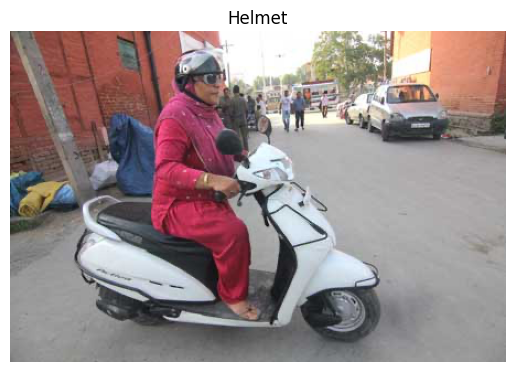

In [ ]:
import cv2
import numpy as np
from skimage.feature import hog
from joblib import load
import matplotlib.pyplot as plt

# Load model
model = load("helmet_svm_model.joblib")

# Image upload
from google.colab import files
uploaded = files.upload()
img_path = list(uploaded.keys())[0]

# Read
img = cv2.imread(img_path)
img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
img_resized = cv2.resize(img_gray, (128,128))

# HOG feature
HOG_PARAMS = dict(
    orientations=9, pixels_per_cell=(8,8),
    cells_per_block=(2,2), block_norm='L2-Hys',
    transform_sqrt=True, feature_vector=True
)
feat = hog(img_resized, **HOG_PARAMS).reshape(1,-1)

# Prediction
pred = model.predict(feat)[0]
label = "Helmet" if pred == 1 else "No Helmet"

# Display
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title(label)
plt.axis('off')
plt.show()


In [ ]:
import zipfile

with open("output_2.zip", "rb") as f:
    header = f.read(4)

print(header)


b'PK\x03\x04'


In [ ]:
import os

print(os.path.getsize("output_2.zip"), "bytes")


174063616 bytes


In [ ]:
import zipfile

try:
    with zipfile.ZipFile("output_2.zip", 'r') as zip_ref:
        zip_ref.extractall("unzipped_output")
    print("Extracted Successfully!")
except Exception as e:
    print("Error:", e)


Extracted Successfully!


In [ ]:
import os

for root, dirs, files in os.walk("/content/helmet_data"):
    print(root, " ---> ", len(files), "files")

In [ ]:
from google.colab import files
uploaded = files.upload()


Saving output_2.zip to output_2.zip


In [ ]:
import zipfile

try:
    with zipfile.ZipFile("output_2.zip", "r") as z:
        z.extractall("extracted")
    print("Extracted successfully!")
except Exception as e:
    print("Error:", e)


Extracted successfully!


HOG feature vector shape: (56448,)


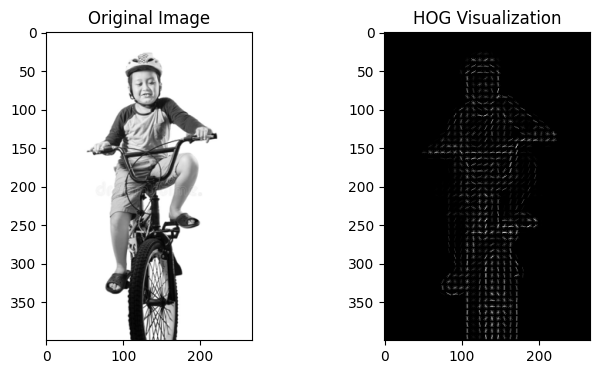

In [ ]:
from skimage.feature import hog
from skimage import io, color
import matplotlib.pyplot as plt

# Load the image
img = io.imread('/content/BikesHelmets86.png')

# If image has alpha channel, drop it
if img.shape[-1] == 4:
    img = img[:, :, :3]

# Convert to grayscale
img_gray = color.rgb2gray(img)

# Extract HOG features
features, hog_image = hog(
    img_gray,
    orientations=9,
    pixels_per_cell=(8, 8),
    cells_per_block=(2, 2),
    block_norm='L2-Hys',
    transform_sqrt=True,
    feature_vector=True,
    visualize=True
)

print("HOG feature vector shape:", features.shape)

# Visualize HOG image
plt.figure(figsize=(8,4))
plt.subplot(1,2,1)
plt.imshow(img_gray, cmap='gray')
plt.title('Original Image')

plt.subplot(1,2,2)
plt.imshow(hog_image, cmap='gray')
plt.title('HOG Visualization')

plt.show()
